In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.topology import (
    # Main classes
    SpatialMapper,
    MapperResult,
    spatial_mapper,
    # Filters
    density_filter,
    eccentricity_filter,
    entropy_filter,
    # Spatial filters
    distance_to_type_filter,
    radial_filter,
    spatial_density_filter,
    composite_filter,
    # Analysis
    node_summary_dataframe,
    find_hub_nodes,
    find_bridge_nodes,
    component_statistics,
    extract_mapper_features,

    find_hub_nodes,
    cells_in_multiple_nodes,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_mapper_graph,
    plot_mapper_spatial,
    plot_filter_distribution,
    plot_node_composition,
)

np.random.seed(42)

## Create Sample Tissue

In [2]:
# Create tissue with spatial structure
# Central tumor cluster
tumor = np.random.normal(loc=[500, 500], scale=80, size=(200, 2))
tumor_types = ['Tumor'] * 200

# Immune cells infiltrating from one side
immune = np.random.normal(loc=[300, 500], scale=100, size=(100, 2))
immune_types = ['CD8_T_cell'] * 100

# Stromal cells on the other side
stromal = np.random.normal(loc=[700, 500], scale=80, size=(80, 2))
stromal_types = ['Stromal'] * 80

# Scattered macrophages
macro = np.random.uniform(100, 900, size=(60, 2))
macro_types = ['Macrophage'] * 60

coordinates = np.vstack([tumor, immune, stromal, macro])
cell_types = np.array(tumor_types + immune_types + stromal_types + macro_types)

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)

SpatialTissueData
  Cells: 440
  Dimensions: 2D
  Cell types: 4
  Bounds: x=[52.8, 905.9], y=[114.3, 890.1]


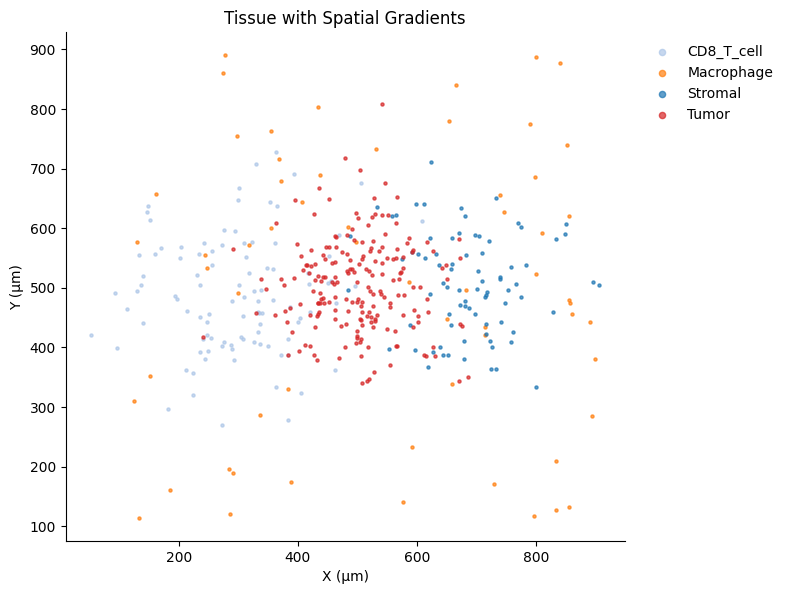

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Tissue with Spatial Gradients')
plt.tight_layout()
plt.show()

## The SpatialMapper Class

In [4]:
mapper = SpatialMapper(
    filter_fn='density',           # Built-in filter
    cover_type='uniform',          # 'uniform' or 'adaptive'
    n_intervals=12,
    overlap=0.4,
    clustering='dbscan',
    clustering_params={'eps': 0.5, 'min_samples': 5},
    min_cluster_size=5,
    min_edge_weight=2              # Minimum shared cells to create edge
)

result = mapper.fit(tissue, neighborhood_radius=50.0)

## The MapperResult Object

In [16]:
# The result contains everything you need
print(f"Number of clusters found: {result.n_nodes}")          # Number of clusters found
print(f"Number of edges found: {result.n_edges}")          # Number of connections
print(f"Number of disconnected subgraphs: {result.n_components}")     # Number of disconnected subgraphs
#print(result.filter_values)    # Filter value for each cell
#print(f"Number of Mapper nodes: {len(result.nodes)}")            # List of MapperNode objects
#print(f"Number of Mapper edges: {len(result.edges)}")            # List of MapperEdge objects
#print(result.graph)           # NetworkX graph (if installed)

# Get cells in a specific node
cells_in_node_4 = result.get_node_members(node_id=4)
print(f"Cells in Node 4: {cells_in_node_4}")

# Get cells in a connected component
cells_in_largest_component = result.get_cells_by_component(component_id=0)
print(f"Cells in the largest component: {cells_in_largest_component}")

Number of clusters found: 23
Number of edges found: 17
Number of disconnected subgraphs: 6
Cells in Node 4: [203 213 214 226 231 242 245 248 249 266 267 280 285 291 383]
Cells in the largest component: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197

## Finding Patterns of Cell-Cell Interactions

Each Mapper node represents a group of cells with similar neighborhood compositions. By examining node compositions, you can identify:

1. Homogeneous neighborhoods: Nodes dominated by one cell type
2. Interaction zones: Nodes with mixed cell types
3. Transition regions: Edges connecting different neighborhood types

### Example: Analyzing Tumor-Immune Interactions

In [17]:
# Create a filter based on distance to immune cells
# This will group cells by their proximity to immune infiltration
result = spatial_mapper(
    tissue,
    filter_fn=distance_to_type_filter('Tumor'),
    n_intervals=15,
    overlap=0.5,
    neighborhood_radius=50.0
)

# Summarize what's in each node
node_df = node_summary_dataframe(result, tissue)

# Each row shows:
# - node_id: unique identifier
# - size: number of cells in this cluster
# - filter_mean: average distance to immune cells
# - count_Tumor, count_Immune, count_Fibroblast: cell type counts
# - prop_Tumor, prop_Immune, prop_Fibroblast: cell type proportions

node_df[['node_id', 'size', 'filter_mean', 'prop_Tumor', 'prop_CD8_T_cell']]

,node_id,size,filter_mean,prop_Tumor,prop_CD8_T_cell
0,0,276,0.011267,0.721014,0.137681
1,1,72,0.097818,NaN,0.541667
2,2,25,0.156569,NaN,0.800000
3,3,21,0.154434,NaN,NaN
4,4,15,0.239626,NaN,0.933333
5,5,12,0.234748,NaN,NaN
6,6,10,0.284741,NaN,0.900000
7,7,14,0.302905,NaN,0.071429
8,8,3,0.299863,NaN,NaN
9,9,5,0.365176,NaN,0.600000


Interpretation: Node 0 has a low filter mean and high proportion of tumor present. This suggests that this node composes the CD8 T cell to Tumor cell interface.

### Example: Finding Recurring Neighborhood Patterns

In [20]:
# Use entropy filter to find diverse vs. homogeneous neighborhoods
result = spatial_mapper(
    tissue,
    filter_fn=entropy_filter(),  # Diversity of cell types in neighborhood
    n_intervals=10,
    overlap=0.5
)

# Find "hub" nodes - central nodes that connect many others
hubs = find_hub_nodes(result, n_hubs=5, metric='betweenness')
print("Hub nodes (potential transition zones):")
for node_id, score in hubs:
    node_comp = result.graph.nodes[node_id].get('composition', {})
    print(f"  Node {node_id}: {node_comp}")

# Find cells that appear in multiple nodes (boundary/transition cells)
boundary_cells = cells_in_multiple_nodes(result)
print(f"\n{len(boundary_cells)} cells are in multiple Mapper nodes")
print("These may represent transitional cell states or boundary regions")

Hub nodes (potential transition zones):
  Node 16: {np.str_('CD8_T_cell'): np.int64(14), np.str_('Macrophage'): np.int64(14), np.str_('Stromal'): np.int64(18), np.str_('Tumor'): np.int64(57)}
  Node 17: {np.str_('CD8_T_cell'): np.int64(20), np.str_('Macrophage'): np.int64(11), np.str_('Stromal'): np.int64(20), np.str_('Tumor'): np.int64(36)}
  Node 13: {np.str_('CD8_T_cell'): np.int64(9), np.str_('Macrophage'): np.int64(2), np.str_('Stromal'): np.int64(3), np.str_('Tumor'): np.int64(53)}
  Node 10: {np.str_('CD8_T_cell'): np.int64(5), np.str_('Macrophage'): np.int64(1), np.str_('Stromal'): np.int64(2), np.str_('Tumor'): np.int64(38)}
  Node 7: {np.str_('Stromal'): np.int64(3), np.str_('Tumor'): np.int64(31)}

164 cells are in multiple Mapper nodes
These may represent transitional cell states or boundary regions
